# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent.parent
sns.set_style("darkgrid")
print("✅ Visualization setup complete")

✅ Visualization setup complete


# Load Data

In [2]:
df = pd.read_parquet(PROJECT_ROOT / 'data/features/engineered_features.parquet')
print(f"📊 Loaded {df.shape[0]} samples, {df.shape[1]} features")

📊 Loaded 3887 samples, 25 features


# Correlation Matrix

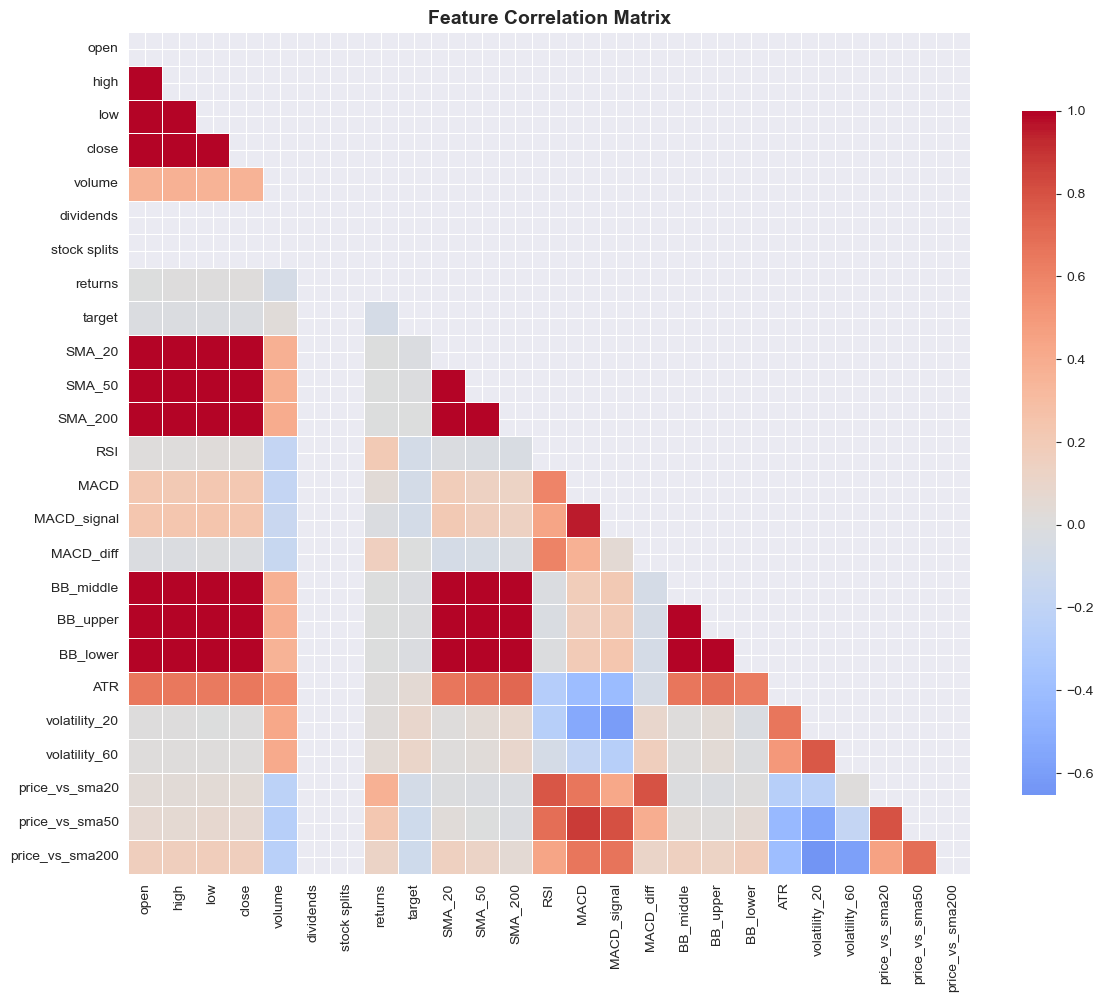

✅ Correlation matrix saved


In [3]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'visualizations/plots/correlation_matrix.png', dpi=150)
plt.show()
print("✅ Correlation matrix saved")

# Feature Importance

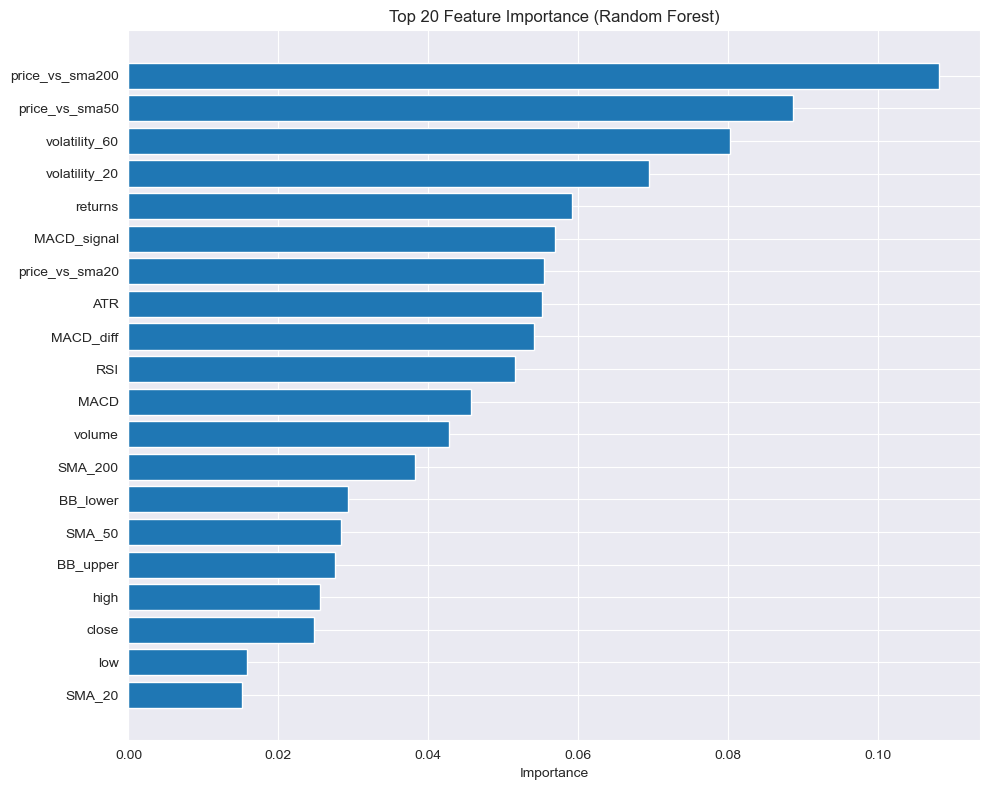

✅ Feature importance plot saved


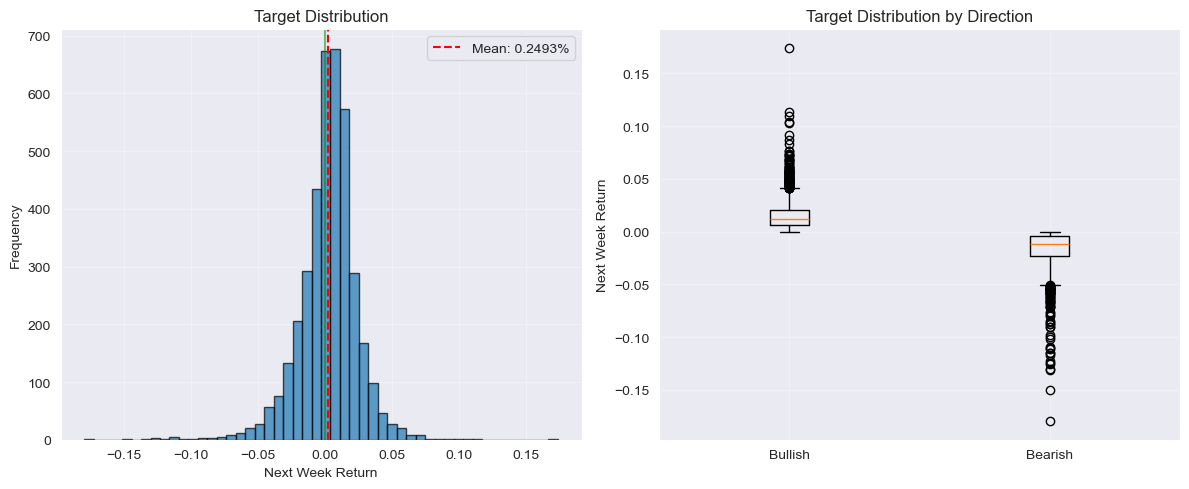

✅ Target distribution plots saved


In [4]:
from sklearn.ensemble import RandomForestRegressor

# Calculate feature importance
X = df.drop('target', axis=1)
y = df['target']
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'visualizations/plots/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance plot saved")

# Cell 5: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution
axes[0].hist(df['target'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['target'].mean(), color='r', linestyle='--', 
                label=f'Mean: {df["target"].mean():.4%}')
axes[0].axvline(0, color='g', linestyle='-', alpha=0.5)
axes[0].set_xlabel('Next Week Return')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by direction
df['direction'] = df['target'] > 0
axes[1].boxplot([df[df['direction']]['target'], df[~df['direction']]['target']], 
                labels=['Bullish', 'Bearish'])
axes[1].set_ylabel('Next Week Return')
axes[1].set_title('Target Distribution by Direction')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'visualizations/plots/target_distribution.png', dpi=150)
plt.show()
print("✅ Target distribution plots saved")